# CoNSeP 原图与分割掩码可视化
输入图像名后，本 notebook 会自动在 Train/Test 中查找对应图像与 `.mat` 标注。
显示结果为一张叠加图：原始图像作为底图，不同类别的细胞实例以不同颜色覆盖显示。

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage
from scipy.io import loadmat

DATA_ROOT = Path('.')
IMAGE_NAME = 'train_1'

CLASS_INFO = {
    1: ('other', '#ffffff'),
    2: ('inflammatory', '#00e5ff'),
    3: ('healthy epithelial', '#ff1744'),
    4: ('dysplastic/malignant epithelial', '#ff1744'),
    5: ('fibroblast', '#00e676'),
    6: ('muscle', '#ff9100'),
    7: ('endothelial', '#00e676'),
}

def resolve_sample_paths(image_name: str, data_root: Path):
    image_name = image_name.strip()
    stem = Path(image_name).stem
    candidates = [
        (data_root / 'Train' / 'Images' / f'{stem}.png', data_root / 'Train' / 'Labels' / f'{stem}.mat'),
        (data_root / 'Test' / 'Images' / f'{stem}.png', data_root / 'Test' / 'Labels' / f'{stem}.mat'),
    ]
    for image_path, label_path in candidates:
        if image_path.exists() and label_path.exists():
            return image_path, label_path
    raise FileNotFoundError(f'未找到图像或标注: {image_name}')


def build_boundary_overlay(type_map: np.ndarray, boundary_width: int = 2):
    overlay = np.zeros((*type_map.shape, 4), dtype=np.float32)
    structure = np.ones((3, 3), dtype=bool)
    for class_id, (_, color_hex) in CLASS_INFO.items():
        mask = type_map == class_id
        if not np.any(mask):
            continue
        eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
        boundary = mask & (~eroded)
        if boundary_width > 1:
            boundary = ndimage.binary_dilation(boundary, structure=structure, iterations=boundary_width - 1)
        rgb = np.array([int(color_hex[i:i + 2], 16) for i in (1, 3, 5)], dtype=np.float32) / 255.0
        overlay[boundary, :3] = rgb
        overlay[boundary, 3] = 1.0
    return overlay

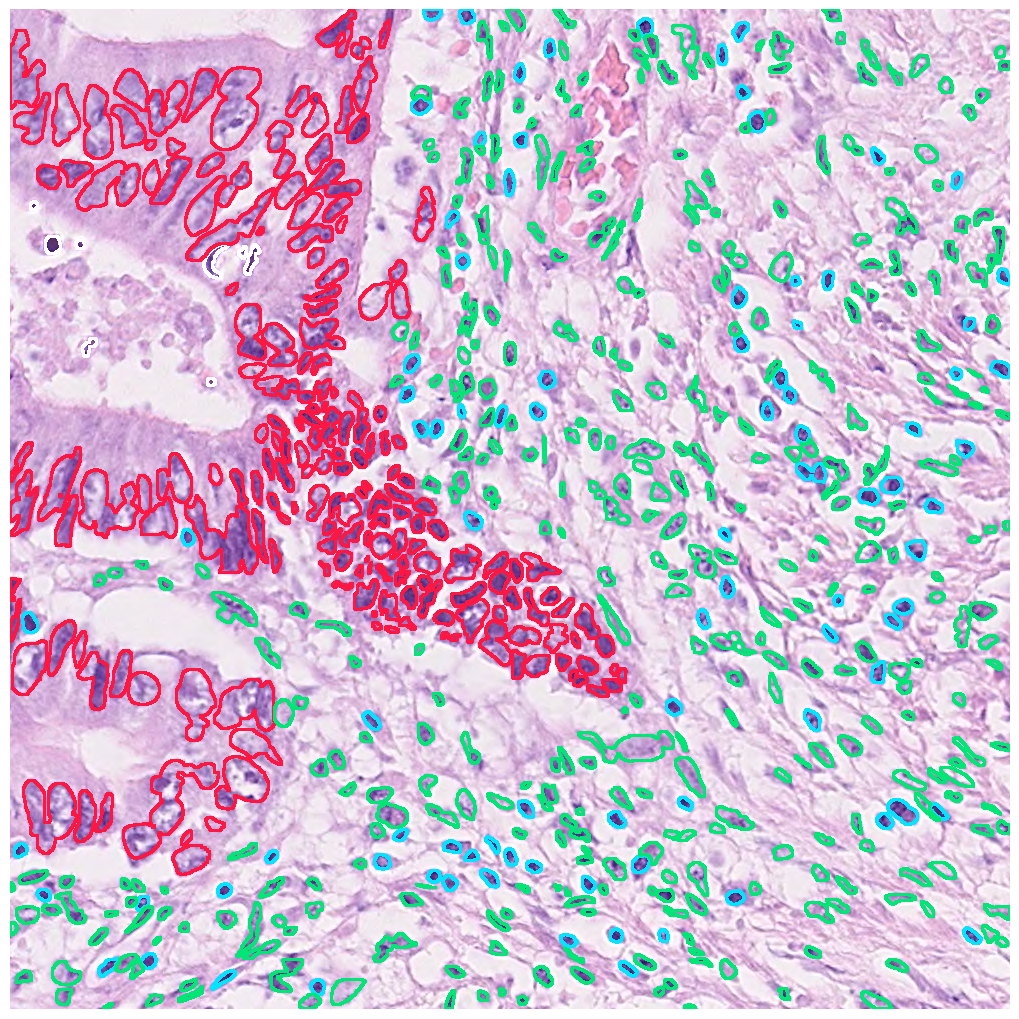

In [16]:
image_path, label_path = resolve_sample_paths(IMAGE_NAME, DATA_ROOT)

image = np.array(Image.open(image_path).convert('RGB'))
label_mat = loadmat(label_path)
type_map = label_mat['type_map']

overlay = build_boundary_overlay(type_map, boundary_width=2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image)
ax.imshow(overlay)
ax.axis('off')
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.show()